### En este Notebook revisaremos el proceso de manejo de MV.

Primero trabajeremos con un dataset pequeño y luego con un data set más grande.

In [2]:
import numpy as np
import pandas as pd


Como se darán cuenta, el valor **np.nan** es una forma común de reflejar la presencia de MV.

No siempre es asi. Como vimos en la clase teórica, aveces pueden encontrar otros símbolos como: espacios en blanco, signos de interrogación, etc.

In [3]:
datos = {'alumno': ['Zutano', 'Mengano', 'Zutano','Pepe' ,'Fulanito, Cosme', 'Maria', 'Juan', 'Pablo', 'Ana'],
         'Primera prueba': [np.nan, 8.5,7,7,np.nan, 4.5, 7.5, 1.0, 8.8],
         'Segunda prueba': [10,np.nan,9.8,4,np.nan,np.nan, 2.5, np.nan, np.nan],
         'observaciones':['ninguna','libre','ninguna','ninguna','libre','oyente','ninguna','libre','oyente'],
         'DNI':[23000000, 12389100,23000000, 99999, 1001,30406011, 1230000, 86758444, 9996696]}
df = pd.DataFrame(datos)
df

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
0,Zutano,NaN,10.0,ninguna,23000000
1,Mengano,8.5,NaN,libre,12389100
2,Zutano,7.0,9.8,ninguna,23000000
3,Pepe,7.0,4.0,ninguna,99999
4,"Fulanito, Cosme",NaN,NaN,libre,1001
5,Maria,4.5,NaN,oyente,30406011
6,Juan,7.5,2.5,ninguna,1230000
7,Pablo,1.0,NaN,libre,86758444
8,Ana,8.8,NaN,oyente,9996696


### Eliminación de filas o columnas con MV

Eliminamos las filas que tienen NaN. Para eso usamos el método df.dropna()

In [4]:
df_2 = df.dropna()
df_2

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
2,Zutano,7.0,9.8,ninguna,23000000
3,Pepe,7.0,4.0,ninguna,99999
6,Juan,7.5,2.5,ninguna,1230000


Observemos que había varias maneras de hacer esto. Por ejemplo, podríamos haber querido eliminar las columnas que tenían un NaN, en vez de las filas:

In [5]:
df_3 = df.dropna(axis=1)
df_3

,alumno,observaciones,DNI
0,Zutano,ninguna,23000000
1,Mengano,libre,12389100
2,Zutano,ninguna,23000000
3,Pepe,ninguna,99999
4,"Fulanito, Cosme",libre,1001
5,Maria,oyente,30406011
6,Juan,ninguna,1230000
7,Pablo,libre,86758444
8,Ana,oyente,9996696


### Podemos usar técnicas de imputación.

In [6]:
# Volvemos a mostrar los datos iniciales
df

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
0,Zutano,NaN,10.0,ninguna,23000000
1,Mengano,8.5,NaN,libre,12389100
2,Zutano,7.0,9.8,ninguna,23000000
3,Pepe,7.0,4.0,ninguna,99999
4,"Fulanito, Cosme",NaN,NaN,libre,1001
5,Maria,4.5,NaN,oyente,30406011
6,Juan,7.5,2.5,ninguna,1230000
7,Pablo,1.0,NaN,libre,86758444
8,Ana,8.8,NaN,oyente,9996696


Imputaremos por la media observable de la columna "Primera prueba" y "Segunda prueba"

In [7]:
a = df['Primera prueba']
b = df['Segunda prueba']
prom_a = a.mean()
prom_b = b.mean()

# Una forma simple es usar un diccionario para guardar la información.
#La llaves del diccionario son los nombres de las variables (columnas) y el valor asociado es el promedio
diccionario = {'Primera prueba':prom_a, 'Segunda prueba': prom_b}

# El método .fillna sirve para reemplazar los valores NaN por los que queremos.
df2 = df.fillna(diccionario)
df2

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
0,Zutano,6.328571,10.000,ninguna,23000000
1,Mengano,8.500000,6.575,libre,12389100
2,Zutano,7.000000,9.800,ninguna,23000000
3,Pepe,7.000000,4.000,ninguna,99999
4,"Fulanito, Cosme",6.328571,6.575,libre,1001
5,Maria,4.500000,6.575,oyente,30406011
6,Juan,7.500000,2.500,ninguna,1230000
7,Pablo,1.000000,6.575,libre,86758444
8,Ana,8.800000,6.575,oyente,9996696


Como se habra dado cuenta, el dataframe se ve modificado segun el valor promedio de la variable respectiva. Esto puede ser útil, a veces, pero otras no.

Por ejemplo, en la variable: "Segunda prueba", existe 3 MV. Esto es el 50% de los datos. Eso puede tener una repercusión fuerte en la distribución de los datos.

### ¿Qué tipo de gráfico nos puede mostrar la distribución de los datos?

### Hacer un grafico que permita ver la distribucion de los datos de las variables: "Primera prueba" y "Segunda prueba" permitirá ver la influencia de la imputación.


In [8]:
import matplotlib.pyplot as plt

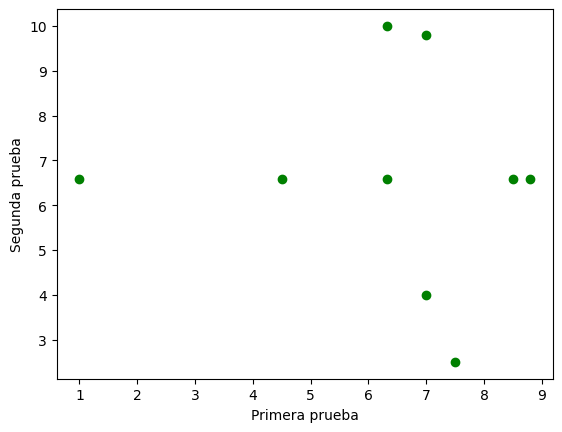

In [9]:
plt.scatter(df2['Primera prueba'], df2['Segunda prueba'], c="g", alpha=1,)
plt.xlabel("Primera prueba")
plt.ylabel("Segunda prueba")
plt.show()

In [10]:
# aca obtenemos los indices donde hay datos.
bol = np.isnan(df['Primera prueba'])
indices = np.where(bol==False)[0]
indices

array([1, 2, 3, 5, 6, 7, 8])

In [11]:
bol

0     True
1    False
2    False
3    False
4     True
5    False
6    False
7    False
8    False
Name: Primera prueba, dtype: bool

In [12]:
# verificamos si solo obtenemos datos y no los MV
data_filtrada1 = df['Primera prueba'][indices]
data_filtrada1

1    8.5
2    7.0
3    7.0
5    4.5
6    7.5
7    1.0
8    8.8
Name: Primera prueba, dtype: float64

In [13]:
# hacemos lo mismo con la segunda variable
bol = np.isnan(df['Segunda prueba'])
indices = np.where(bol==False)[0]
data_filtrada2 = df['Segunda prueba'][indices]
data_filtrada2

0    10.0
2     9.8
3     4.0
6     2.5
Name: Segunda prueba, dtype: float64

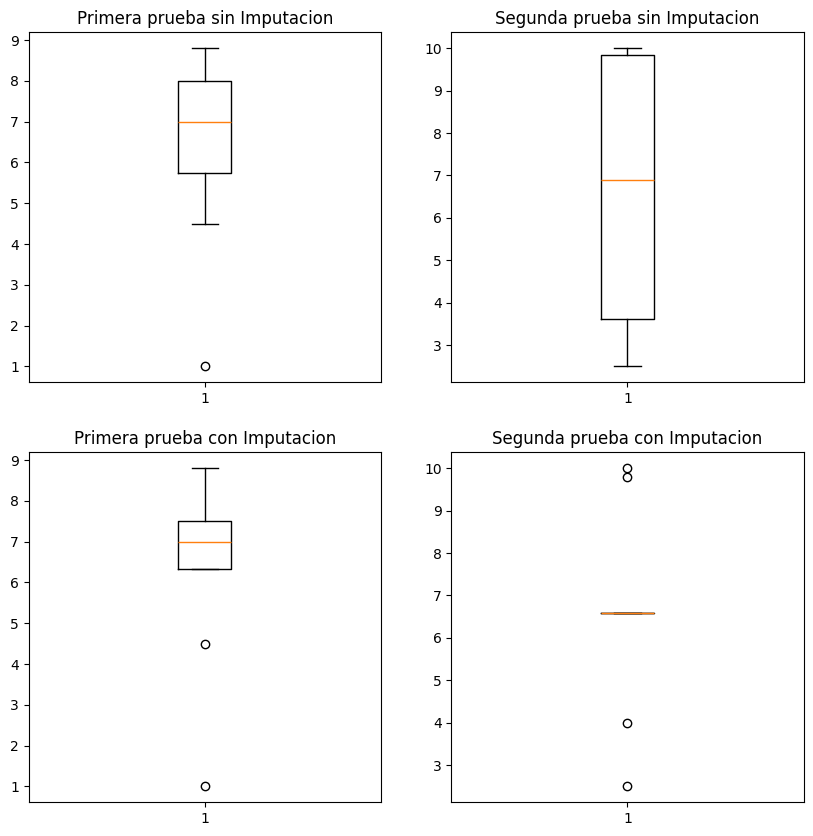

In [14]:
fig1, axs = plt.subplots(2,2, figsize=(10,10))
axs[0,0].set_title('Primera prueba sin Imputacion')
axs[0,0].boxplot(data_filtrada1)
axs[0,1].set_title('Segunda prueba sin Imputacion')
axs[0,1].boxplot(data_filtrada2)
axs[1,0].set_title('Primera prueba con Imputacion')
axs[1,0].boxplot(df2['Primera prueba'])
axs[1,1].set_title('Segunda prueba con Imputacion')
axs[1,1].boxplot(df2['Segunda prueba'])

plt.show()

## Veremos como usar la imputación de MV mediante la técnica de K-NN

La manera más sencilla es usar la función KNNImputer de la libreria ScikitLearn.

Pueden encontrar información de la función [AQUI](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html)

In [15]:
# primero importaremos lo necesario
from sklearn.impute import KNNImputer

Usaremos el data set del ejemplo anterior:

In [16]:
datos = {'alumno': ['Zutano', 'Mengano', 'Zutano','Pepe' ,'Fulanito, Cosme', 'Maria', 'Juan', 'Pablo', 'Ana'],
         'Primera prueba': [np.nan, 8.5,7,7,np.nan, 4.5, 7.5, 1.0, 8.8],
         'Segunda prueba': [10,np.nan,9.8,4,np.nan,np.nan, 2.5, np.nan, np.nan],
         'observaciones':['ninguna','libre','ninguna','ninguna','libre','oyente','ninguna','libre','oyente'],
         'DNI':[23000000, 12389100,23000000, 99999, 1001, 30406011, 1230000, 86758444, 9996696]}
df = pd.DataFrame(datos)
df

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
0,Zutano,NaN,10.0,ninguna,23000000
1,Mengano,8.5,NaN,libre,12389100
2,Zutano,7.0,9.8,ninguna,23000000
3,Pepe,7.0,4.0,ninguna,99999
4,"Fulanito, Cosme",NaN,NaN,libre,1001
5,Maria,4.5,NaN,oyente,30406011
6,Juan,7.5,2.5,ninguna,1230000
7,Pablo,1.0,NaN,libre,86758444
8,Ana,8.8,NaN,oyente,9996696


In [17]:
# vamos a crear una copia de los datos originales
datos_knn = datos.copy()
datos_knn = pd.DataFrame(datos_knn)
datos_knn

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
0,Zutano,NaN,10.0,ninguna,23000000
1,Mengano,8.5,NaN,libre,12389100
2,Zutano,7.0,9.8,ninguna,23000000
3,Pepe,7.0,4.0,ninguna,99999
4,"Fulanito, Cosme",NaN,NaN,libre,1001
5,Maria,4.5,NaN,oyente,30406011
6,Juan,7.5,2.5,ninguna,1230000
7,Pablo,1.0,NaN,libre,86758444
8,Ana,8.8,NaN,oyente,9996696


In [18]:
# creamos un objeto de KNN imputer. con 2 vecinos y parámetro weights = uniform. AVERIGUE QUE SIGNIFIQUE ESTE ULTIMO PARAMETRO!!
knn_imputer = KNNImputer(n_neighbors=1, weights="uniform")

### Es importante entregarle variables con datos numéricos. Ya que se calculan distancias y la distancia por defecto es la Euclidiana.

In [19]:
datos_knn[['Primera prueba', 'Segunda prueba']] = knn_imputer.fit_transform(datos_knn[['Primera prueba', 'Segunda prueba']])
datos_knn

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
0,Zutano,7.000000,10.000,ninguna,23000000
1,Mengano,8.500000,2.500,libre,12389100
2,Zutano,7.000000,9.800,ninguna,23000000
3,Pepe,7.000000,4.000,ninguna,99999
4,"Fulanito, Cosme",6.328571,6.575,libre,1001
5,Maria,4.500000,9.800,oyente,30406011
6,Juan,7.500000,2.500,ninguna,1230000
7,Pablo,1.000000,9.800,libre,86758444
8,Ana,8.800000,2.500,oyente,9996696


### TAREA EN CLASES (15 MINUTOS)

#### Pruebe variando el valor de K.

In [43]:
datos_knn = datos.copy()
datos_knn = pd.DataFrame(datos_knn)
datos_knn

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
0,Zutano,NaN,10.0,ninguna,23000000
1,Mengano,8.5,NaN,libre,12389100
2,Zutano,7.0,9.8,ninguna,23000000
3,Pepe,7.0,4.0,ninguna,99999
4,"Fulanito, Cosme",NaN,NaN,libre,1001
5,Maria,4.5,NaN,oyente,30406011
6,Juan,7.5,2.5,ninguna,1230000
7,Pablo,1.0,NaN,libre,86758444
8,Ana,8.8,NaN,oyente,9996696


In [ ]:
# creamos un objeto de KNN imputer. con 2 vecinos y parámetro weights = uniform. AVERIGUE QUE SIGNIFICA ESTE ULTIMO PARAMETRO!!
knn_imputer = KNNImputer(n_neighbors=2, weights="uniform")
datos_knn[['Primera prueba', 'Segunda prueba']] = knn_imputer.fit_transform(datos_knn[['Primera prueba', 'Segunda prueba']])
datos_knn

,alumno,Primera prueba,Segunda prueba,observaciones,DNI
0,Zutano,7.166667,10.000000,ninguna,23000000
1,Mengano,8.500000,5.433333,libre,12389100
2,Zutano,7.000000,9.800000,ninguna,23000000
3,Pepe,7.000000,4.000000,ninguna,99999
4,"Fulanito, Cosme",6.328571,6.575000,libre,1001
5,Maria,4.500000,5.433333,oyente,30406011
6,Juan,7.500000,2.500000,ninguna,1230000
7,Pablo,1.000000,5.433333,libre,86758444
8,Ana,8.800000,5.433333,oyente,9996696


# Como identificamos MV si no se usan nan

Haremos un ejemplo con un dataset de diabetes, donde los MV estan ejemplificados con un ?

In [ ]:
import pandas as pd

columnas = [
    "surgery", "age", "hospital_number", "rectal_temperature", "pulse",
    "respiratory_rate", "temp_extremities", "peripheral_pulse", "mucous_membranes",
    "capillary_refill_time", "pain", "peristalsis", "abdominal_distension",
    "nasogastric_tube", "nasogastric_reflux", "nasogastric_reflux_ph",
    "rectal_exam_feces", "abdomen", "packed_cell_volume", "total_protein",
    "abdominocentesis_appearance", "abdomcentesis_total_protein", "outcome",
    "surgical_lesion", "lesion_1", "lesion_2", "lesion_3", "cp_data",
]

df = pd.read_csv(
    "1.3.3 Dataset_diabetes.csv",
    sep=",",
    header=None,          # el archivo no tiene fila de encabezado
    names=columnas,
    na_values=("?")         # los faltantes vienen como "?"
)
df.head()


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temp_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdomcentesis_total_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
1,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
2,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2
3,2.0,1,528355,NaN,NaN,NaN,2.0,1.0,3.0,1.0,...,NaN,NaN,NaN,NaN,1.0,2,0,0,0,2
4,1.0,1,526802,37.9,48.0,16.0,1.0,1.0,1.0,1.0,...,37.0,7.0,NaN,NaN,1.0,1,3124,0,0,2


Revisamos cuantos MV hay por variable

In [56]:
for i in range(df.shape[1]):
    col = df.columns[i]
    n_miss = int(df.iloc[:, i].isnull().sum())
    perc = round(n_miss / df.shape[0] * 100, 1)
    print(f"\n{col}, Missing: {n_miss} ({perc}%)")



surgery, Missing: 1 (0.3%)

age, Missing: 0 (0.0%)

hospital_number, Missing: 0 (0.0%)

rectal_temperature, Missing: 60 (20.1%)

pulse, Missing: 24 (8.1%)

respiratory_rate, Missing: 58 (19.5%)

temp_extremities, Missing: 55 (18.5%)

peripheral_pulse, Missing: 68 (22.8%)

mucous_membranes, Missing: 46 (15.4%)

capillary_refill_time, Missing: 32 (10.7%)

pain, Missing: 55 (18.5%)

peristalsis, Missing: 44 (14.8%)

abdominal_distension, Missing: 56 (18.8%)

nasogastric_tube, Missing: 102 (34.2%)

nasogastric_reflux, Missing: 104 (34.9%)

nasogastric_reflux_ph, Missing: 245 (82.2%)

rectal_exam_feces, Missing: 102 (34.2%)

abdomen, Missing: 118 (39.6%)

packed_cell_volume, Missing: 29 (9.7%)

total_protein, Missing: 33 (11.1%)

abdominocentesis_appearance, Missing: 164 (55.0%)

abdomcentesis_total_protein, Missing: 197 (66.1%)

outcome, Missing: 1 (0.3%)

surgical_lesion, Missing: 0 (0.0%)

lesion_1, Missing: 0 (0.0%)

lesion_2, Missing: 0 (0.0%)

lesion_3, Missing: 0 (0.0%)

cp_data, Mi